# Next Best Financial Offer (NBFO) — Xây dựng Master Table

**Mục tiêu notebook:** Gộp 6 bảng dữ liệu đã tiền xử lý (`customer`, `lending`, `deposit`, `card`, `transaction`, `activity`) thành **một Master Table** duy nhất ở mức khách hàng (1 dòng = 1 `CUSTOMER_NUMBER`), sau đó xử lý toàn diện: chuẩn hoá kiểu dữ liệu, encode biến phân loại, xử lý missing value, xử lý outlier, feature engineering và EDA.

Master Table này sẽ là **input** cho bài toán B (NBFO) — mô hình propensity dự đoán xác suất khách hàng chấp nhận sản phẩm tài chính mới.

**Cấu trúc notebook:**
1. Import thư viện & Load dữ liệu
2. Khảo sát sơ bộ từng bảng
3. Gộp thành Master Table (merge strategy)
4. Chuẩn hoá kiểu dữ liệu
5. Xử lý Missing Value
6. Encode biến phân loại
7. Xử lý Outlier
8. Feature Engineering
9. EDA & Visualization
10. Xuất Master Table hoàn chỉnh


## 1. Import thư viện & Load dữ liệu

**Mục tiêu:** Chuẩn bị môi trường làm việc và đọc 6 bảng đầu vào.

**Vì sao:** Đọc dữ liệu ngay từ đầu để có cái nhìn tổng quan về shape, dtype trước khi quyết định chiến lược gộp bảng.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42

In [22]:
customer    = pd.read_csv("customer_clean.csv", low_memory = False)
lending     = pd.read_csv("lending_clean.csv")
deposit     = pd.read_csv("deposit_clean.csv")
card        = pd.read_csv("card_clean.csv")
transaction = pd.read_csv("transaction_clean.csv")
activity    = pd.read_csv("activity_clean.csv", low_memory = False)

tables = {
    "customer": customer,
    "lending": lending,
    "deposit": deposit,
    "card": card,
    "transaction": transaction,
    "activity": activity
}

for name, df in tables.items():
    print(f"{name:12s} | shape = {df.shape} \t| unique customers = {df['CUSTOMER_NUMBER'].nunique()}")

customer     | shape = (290223, 21) 	| unique customers = 290223
lending      | shape = (73861, 15) 	| unique customers = 73861
deposit      | shape = (159440, 23) 	| unique customers = 159440
card         | shape = (104342, 10) 	| unique customers = 104342
transaction  | shape = (29882, 26) 	| unique customers = 29882
activity     | shape = (47589, 33) 	| unique customers = 47589


## 2. Khảo sát sơ bộ từng bảng

**Mục tiêu:** Hiểu vai trò của từng bảng trong việc gộp: bảng nào là *base* (chứa toàn bộ khách hàng), bảng nào là *subset* (chỉ chứa khách hàng có sử dụng sản phẩm/dịch vụ tương ứng).

**Vì sao quan trọng:** Nếu không xác định đúng bảng *base*, việc `merge` có thể làm mất khách hàng (nếu dùng `inner join`) hoặc tạo sai ý nghĩa cho giá trị missing sau khi gộp.

In [ ]:
summary = []
for name, df in tables.items():
    summary.append({
        "table": name,
        "n_rows": df.shape[0],
        "n_cols": df.shape[1],
        "n_customers": df["CUSTOMER_NUMBER"].nunique(),
        "dup_customer": df["CUSTOMER_NUMBER"].duplicated().sum()
    })
pd.DataFrame(summary)

,table,n_rows,n_cols,n_customers,dup_customer
0,customer,290223,21,290223,0
1,lending,73861,15,73861,0
2,deposit,159440,23,159440,0
3,card,104342,10,104342,0
4,transaction,29882,26,29882,0
5,activity,47589,33,47589,0


**Nhận xét:**
- `customer` có số dòng lớn nhất (~290k) và không trùng `CUSTOMER_NUMBER` → đây là **bảng gốc (base table)**, đại diện cho *toàn bộ* khách hàng của ngân hàng.
- `lending`, `deposit`, `card`, `transaction`, `activity` đều có số dòng nhỏ hơn → đây là các **bảng subset**, chỉ chứa những khách hàng *có phát sinh* sản phẩm/hoạt động tương ứng (vay, tiền gửi, thẻ, giao dịch, hoạt động trên kênh số).
- → Chiến lược merge: dùng **LEFT JOIN** từ `customer` sang 5 bảng còn lại theo khóa `CUSTOMER_NUMBER`. Khách hàng không xuất hiện ở bảng subset sẽ có giá trị NaN — bản thân điều này **có ý nghĩa nghiệp vụ** (khách hàng chưa từng dùng sản phẩm đó), nên sẽ được xử lý riêng ở bước Missing Value chứ không loại bỏ.

In [ ]:
# Kiểm tra tên cột trùng lặp giữa các bảng con (ngoại trừ khóa CUSTOMER_NUMBER)
# để tránh xung đột (column collision) khi merge

sub_tables = {k: v for k, v in tables.items() if k != "customer"}
names = list(sub_tables.keys())
overlaps = {}

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        cols_i = set(sub_tables[names[i]].columns) - {"CUSTOMER_NUMBER"}
        cols_j = set(sub_tables[names[j]].columns) - {"CUSTOMER_NUMBER"}
        common = cols_i & cols_j
        if common:
            overlaps[(names[i], names[j])] = common

overlaps

{('lending', 'deposit'): {'RECENCY_MONTHS'},
 ('lending', 'transaction'): {'RECENCY_MONTHS'},
 ('deposit', 'transaction'): {'RECENCY_MONTHS'}}

**Phát hiện:** Cột `RECENCY_MONTHS` xuất hiện trùng tên ở 3 bảng `lending`, `deposit`, `transaction` nhưng mang **ý nghĩa khác nhau** (số tháng gần nhất kể từ lần vay/gửi tiền/giao dịch cuối). Nếu merge trực tiếp, pandas sẽ tự thêm hậu tố `_x`, `_y` gây khó hiểu → cần **đổi tên (prefix) trước khi merge** để giữ ý nghĩa rõ ràng.

In [ ]:
lending     = lending.rename(columns = {"RECENCY_MONTHS": "LOAN_RECENCY_MONTHS"})
deposit     = deposit.rename(columns = {"RECENCY_MONTHS": "DEPOSIT_RECENCY_MONTHS"})
transaction = transaction.rename(columns={"RECENCY_MONTHS": "TXN_RECENCY_MONTHS"})
print("Đã đổi tên xong, không còn cột trùng!")

Đã đổi tên xong, không còn cột trùng!


## 3. Gộp thành Master Table

**Mục tiêu:** Tạo 1 bảng duy nhất, mỗi dòng là 1 khách hàng, đầy đủ thông tin từ 6 nguồn.

**Vì sao dùng LEFT JOIN từ `customer`:** Đảm bảo giữ lại **toàn bộ** khách hàng trong hệ thống (kể cả khách hàng chưa dùng sản phẩm nào), vì mục tiêu bài toán NBFO là dự đoán cho *tất cả* khách hàng — kể cả nhóm chưa có sản phẩm (đây chính là nhóm tiềm năng cross-sell quan trọng nhất).

In [27]:
master = customer.copy()
for name in ["lending", "deposit", "card", "transaction", "activity"]:
    df = tables[name] if name != "lending" else lending
    src = {"lending": lending,
           "deposit": deposit,
           "card": card,
           "transaction": transaction,
           "activity": activity}[name]
    master = master.merge(src, on = "CUSTOMER_NUMBER", how = "left", suffixes = ("", f"_{name}_DUP"))

print("Master table shape:", master.shape)
master.head(3)

Master table shape: (290223, 123)


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,DOB_RAW_BACKUP,DOB_YEAR_RAW,DOB_INVALID_FORMAT,SEX_MISSING,DOB_MISSING,IS_THIN_PROFILE,AGE_AT_CREATE,AGE_OUTLIER,DOB_SUSPECTED_DEFAULT,STAFF,HAS_IB_ACCOUNT,DAYS_TO_REGISTER,VERIFY_METHOD_ANOMALY,LATEST_LOAN_COUNT,LATEST_AVG_LOAN_AMOUNT,LOG_LATEST_AVG_LOAN_AMOUNT,HAS_ACTIVE_LOAN_OBS,LOAN_ACTIVE_MONTHS,MAX_HIST_LOAN_COUNT,MAX_HIST_LOAN_AMOUNT,MEAN_HIST_LOAN_AMOUNT,LOG_MAX_HIST_LOAN_AMOUNT,LOG_MEAN_HIST_LOAN_AMOUNT,LOAN_AMOUNT_GROWTH,LOAN_COUNT_GROWTH,LOAN_AMOUNT_GROWTH_RATE,LOAN_RECENCY_MONTHS,LATEST_CA_COUNT,LATEST_AVG_CA_BALANCE,LATEST_TD_COUNT,LATEST_AVG_TD_BALANCE,LOG_LATEST_AVG_CA_BALANCE,LOG_LATEST_AVG_TD_BALANCE,HAS_CA_OBS,HAS_TD_OBS,DEPOSIT_ACTIVE_MONTHS,MAX_HIST_CA_BALANCE,MEAN_HIST_CA_BALANCE,MAX_HIST_TD_BALANCE,MEAN_HIST_TD_BALANCE,LOG_MAX_HIST_CA_BALANCE,LOG_MEAN_HIST_CA_BALANCE,LOG_MAX_HIST_TD_BALANCE,LOG_MEAN_HIST_TD_BALANCE,CA_BALANCE_GROWTH,TD_BALANCE_GROWTH,CA_BALANCE_GROWTH_RATE,TD_BALANCE_GROWTH_RATE,DEPOSIT_RECENCY_MONTHS,LATEST_CREDITCARD_COUNT,LATEST_DEBITCARD_COUNT,HAS_CREDITCARD_OBS,HAS_DEBITCARD_OBS,CARD_ACTIVE_MONTHS,MAX_HIST_CREDITCARD,MAX_HIST_DEBITCARD,CREDITCARD_GROWTH,DEBITCARD_GROWTH,LATEST_TXN_COUNT,LATEST_TOTAL_TRANS_AMOUNT,LATEST_AVG_TRANS_AMOUNT_PER_TXN,LATEST_N_DISTINCT_TRANS_TYPE,LATEST_WEEKEND_AMOUNT_RATIO,LATEST_NIGHT_AMOUNT_RATIO,LATEST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_LATEST_TOTAL_TRANS_AMOUNT,LOG_LATEST_AVG_TRANS_AMOUNT_PER_TXN,HAS_ACTIVE_TXN_OBS,TXN_ACTIVE_MONTHS,MAX_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TOTAL_TRANS_AMOUNT,MEAN_HIST_TXN_COUNT,MAX_HIST_TXN_COUNT,MEAN_HIST_N_DISTINCT_TRANS_TYPE,MEAN_HIST_WEEKEND_AMOUNT_RATIO,MEAN_HIST_NIGHT_AMOUNT_RATIO,MEAN_HIST_OUTSIDE_BANK_AMOUNT_RATIO,LOG_MAX_HIST_TOTAL_TRANS_AMOUNT,LOG_MEAN_HIST_TOTAL_TRANS_AMOUNT,TOTAL_TRANS_AMOUNT_GROWTH,TXN_COUNT_GROWTH,TOTAL_TRANS_AMOUNT_GROWTH_RATE,TXN_RECENCY_MONTHS,TOTAL_ACTIVITY_COUNT,ACTIVE_DAYS,FIRST_ACTIVITY_DATE,LAST_ACTIVITY_DATE,ACTIVITY_PER_ACTIVE_DAY,ACTIVITY_SPAN_DAYS,ACTIVE_DAY_RATIO,N_DISTINCT_ACTIVITY_NAME,N_DISTINCT_ACTIVITY_GROUP,ACTIVITY_GROUP_ENTROPY,CNT_AUTH_SECURITY,CNT_CREDIT_LOAN,CNT_INQUIRY,CNT_INVEST_SAVING,CNT_PAYMENT,CNT_TRANSFER,CNT_UTILITY,PCT_AUTH_SECURITY,PCT_CREDIT_LOAN,PCT_INQUIRY,PCT_INVEST_SAVING,PCT_PAYMENT,PCT_TRANSFER,PCT_UTILITY,HAS_CREDIT_LOAN_SIGNAL,ACTIVITY_CNT_FIRST_HALF,ACTIVITY_CNT_SECOND_HALF,TREND_RATIO,NEW_IN_SECOND_HALF,MOST_COMMON_HOUR,WEEKEND_ACTIVITY_RATIO,BUSINESS_HOUR_RATIO
0,639362,M,2019-04-23,1996-01-01,2019-04-23,BRANCH,Y,SMS,1/1/1996 0:00,NaN,0,0,0,0,23.307324,0,0,0,1,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,99533.33,0.0,0.0,11.508258,0.0,1.0,0.0,6.0,9371139.87,2.441607e+06,0.0,0.0,16.053145,14.708167,0.0,0.0,66933.33,0.0,13386.6660,0.0,1.0,0.0,1.0,0.0,1.0,6.0,0.0,1.0,0.0,0.0,7.0,2640000.0,3.771429e+05,3.0,0.378788,0.0,0.928030,14.786290,12.840382,1.0,4.0,11191000.0,5307750.0,3.25,7.0,1.5,0.094697,0.208333,0.982008,16.230621,15.484679,-2360000.0,6.0,-7.866667e+05,2.0,67.0,16.0,2019-04-23,2019-09-23,4.19,153.0,0.104,11.0,5.0,1.900222,33.0,0.0,17.0,6.0,4.0,7.0,0.0,0.492537,0.0,0.253731,0.089552,0.059701,0.104478,0.000000,0.0,8.0,59.0,7.375,0.0,21.0,0.045,0.597
1,452440,M,2019-01-11,1999-10-10,2019-01-11,BRANCH,Y,SMART_OTP,10/10/1999 0:00,NaN,0,0,0,0,19.255305,0,0,0,1,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,111633.33,0.0,0.0,11.622984,0.0,1.0,0.0,9.0,188607.14,1.483476e+05,0.0,0.0,12.147427,11.907320,0.0,0.0,-23495.70,0.0,-2936.9625,0.0,1.0,0.0,1.0,0.0,1.0,9.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,13.0,2019-01-11,2019-01-31,4.08,20.0,0.619,8.0,3.0,1.488213,27.0,0.0,14.0,12.0,0.0,0.0,0.0,0.509434,0.0,0.264151,0.226415,0.000000,0.000000,0.000000,0.0,53.0,0.0,NaN,0.0,23.0,0.358,0.509
2,326290,F,2019-05-27,1996-06-29,2019-05-27,BRANCH,Y,SMS,6/29/1996 0:00,NaN,0,0,0,0,22.907598,0,0,0,1,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
# Kiểm tra không có cột bị nhân đôi ngoài ý muốn (suffix _dup)
dup_cols = [c for c in master.columns if "_DUP" in c]
print("Cột trùng (nếu có):", dup_cols)
assert master["CUSTOMER_NUMBER"].duplicated().sum() == 0, "Master table bị nhân dòng!"
print("Số khách hàng:", master["CUSTOMER_NUMBER"].nunique(), "| Số dòng:", master.shape[0])

Cột trùng (nếu có): []
Số khách hàng: 290223 | Số dòng: 290223


**Tạo cờ (flag) sở hữu sản phẩm ở mức tổng quát**, dùng để phân biệt khách hàng có/không có dữ liệu ở từng mảng nghiệp vụ — phục vụ cả bước xử lý missing lẫn feature engineering sau này.

In [30]:
master["HAS_LENDING"]     = master["LATEST_LOAN_COUNT"].notna().astype(int)
master["HAS_DEPOSIT"]      = master["LATEST_CA_COUNT"].notna().astype(int)
master["HAS_CARD"]         = master["LATEST_CREDITCARD_COUNT"].notna().astype(int)
master["HAS_TRANSACTION"]  = master["LATEST_TXN_COUNT"].notna().astype(int)
master["HAS_ACTIVITY"]     = master["TOTAL_ACTIVITY_COUNT"].notna().astype(int)

master[["HAS_LENDING", "HAS_DEPOSIT", "HAS_CARD", "HAS_TRANSACTION", "HAS_ACTIVITY"]].mean().rename("ty_le_so_huu (%)") * 100

HAS_LENDING        25.449740
HAS_DEPOSIT        54.937066
HAS_CARD           35.952354
HAS_TRANSACTION    10.296220
HAS_ACTIVITY       16.397391
Name: ty_le_so_huu (%), dtype: float64

## 4. Chuẩn hoá kiểu dữ liệu

**Mục tiêu:** Đưa các cột về đúng kiểu dữ liệu (ngày tháng → `datetime`, số → `numeric`, phân loại → `category`).

**Vì sao:** Dữ liệu ngày tháng đang ở dạng `str` sau khi đọc CSV; nếu không convert, không thể tính tuổi, thời gian gắn bó (tenure) hay recency chính xác. Kiểu `category` cho biến phân loại giúp tiết kiệm bộ nhớ và rõ ràng hơn khi encode.

In [31]:
date_cols = ["CLIENT_CREATE_DATE", "DATE_OF_BIRTH", "IB_REGISTER_DATE", "FIRST_ACTIVITY_DATE", "LAST_ACTIVITY_DATE"]

for c in date_cols:
    if c in master.columns:
        master[c] = pd.to_datetime(master[c], errors = "coerce")

print(master[date_cols].dtypes)

CLIENT_CREATE_DATE     datetime64[ns]
DATE_OF_BIRTH          datetime64[ns]
IB_REGISTER_DATE       datetime64[ns]
FIRST_ACTIVITY_DATE    datetime64[ns]
LAST_ACTIVITY_DATE     datetime64[ns]
dtype: object


In [32]:
# Cột định danh không phải feature -> giữ nguyên nhưng loại khỏi các bước xử lý số/scale sau này
id_cols = ["CUSTOMER_NUMBER"]

# Cột backup / raw không còn cần thiết cho modeling (đã có bản xử lý DATE_OF_BIRTH, DOB_YEAR_RAW quá thiếu)
drop_raw_cols = ["DOB_RAW_BACKUP", "DOB_YEAR_RAW"]
master = master.drop(columns = [c for c in drop_raw_cols if c in master.columns])
print("Đã loại các cột raw/backup không cần thiết:", drop_raw_cols)

Đã loại các cột raw/backup không cần thiết: ['DOB_RAW_BACKUP', 'DOB_YEAR_RAW']


In [33]:
categorical_cols = ["CLIENT_SEX", "EB_REGISTER_CHANNEL", "SMS", "VERIFY_METHOD"]

for c in categorical_cols:
    master[c] = master[c].astype("category")

master[categorical_cols].describe()

,CLIENT_SEX,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
count,290223,290223,290223,290223
unique,3,5,3,4
top,M,NOT_REGISTERED,NOT_REGISTERED,NOT_REGISTERED
freq,155636,131248,131248,131276


## 5. Xử lý Missing Value

**Mục tiêu:** Xử lý toàn bộ giá trị thiếu trong Master Table theo đúng **ý nghĩa nghiệp vụ**, không xử lý máy móc theo một công thức chung.

**Vì sao phải phân nhóm xử lý:**
- Với các cột đến từ bảng *subset* (lending/deposit/card/transaction/activity): NaN nghĩa là **"khách hàng không có sản phẩm/hoạt động này"** → điền `0` cho cột đếm/số tiền, và một giá trị lớn (hoặc cờ riêng) cho cột "recency" vì "chưa từng phát sinh" khác về bản chất với "phát sinh đã lâu".
- Với các cột nhân khẩu học (`DATE_OF_BIRTH`, `AGE_AT_CREATE`...): NaN là thiếu dữ liệu thật sự → cần điền bằng median/mode hoặc gắn cờ thiếu (đã có sẵn `DOB_MISSING`, `SEX_MISSING`), tránh làm sai lệch phân phối tuổi.
- Với `IB_REGISTER_DATE` / `DAYS_TO_REGISTER`: NaN nghĩa là khách hàng **chưa đăng ký Internet Banking** (khớp với `HAS_IB_ACCOUNT=0`) → không nên điền median vì sẽ tạo ra tenure giả.

In [35]:
missing_report = master.isnull().sum()
missing_report = missing_report[missing_report > 0].sort_values(ascending = False)
missing_pct = (missing_report / len(master) * 100).round(2)
pd.DataFrame({"n_missing": missing_report, "pct_missing": missing_pct})

,n_missing,pct_missing
TREND_RATIO,275736,95.01
LATEST_WEEKEND_AMOUNT_RATIO,260341,89.70
MEAN_HIST_TXN_COUNT,260341,89.70
TOTAL_TRANS_AMOUNT_GROWTH_RATE,260341,89.70
TXN_COUNT_GROWTH,260341,89.70
...,...,...
DEPOSIT_ACTIVE_MONTHS,130783,45.06
HAS_CA_OBS,130783,45.06
LOG_LATEST_AVG_TD_BALANCE,130783,45.06
AGE_AT_CREATE,4344,1.50


**Kiểm chứng trước khi fill 0 cho các cột `LOG_...`:** fill 0 chỉ hợp lý về mặt toán học nếu bước tiền xử lý trước đó dùng biến đổi `log1p` (vì `log1p(0) = 0`), không phải `log` thường (vì `log(0)` không xác định). Kiểm tra chéo giữa cột gốc và cột log tương ứng **ngay trên dữ liệu vừa merge, trước khi fillna** để không bị nhiễu bởi chính bước fill sắp thực hiện.

In [ ]:
# Doi chieu tren du lieu VUA MERGE (chua fillna): voi cac dong ma cot goc that su = 0,
# gia tri LOG_ tuong ung phai = 0 neu bien doi la log1p (vi log1p(0) = 0).
check_pairs = [
    ("LATEST_AVG_CA_BALANCE", "LOG_LATEST_AVG_CA_BALANCE"),
    ("LATEST_AVG_TD_BALANCE", "LOG_LATEST_AVG_TD_BALANCE"),
    ("LATEST_AVG_LOAN_AMOUNT", "LOG_LATEST_AVG_LOAN_AMOUNT"),
    ("LATEST_TOTAL_TRANS_AMOUNT", "LOG_LATEST_TOTAL_TRANS_AMOUNT"),
]

for raw_col, log_col in check_pairs:
    zero_rows = master.loc[master[raw_col] == 0, log_col]
    if len(zero_rows) > 0:
        print(f"{raw_col:30s} -> {log_col:30s} | số dòng gốc = 0 (thật sự): {len(zero_rows):6d} | "
              f"log tương ứng: min = {zero_rows.min():.4f}, max = {zero_rows.max():.4f}")
    else:
        print(f'{raw_col:30s} -> Không có dòng gốc nào thật sự = 0 trong bảng subset')

LATEST_AVG_CA_BALANCE          -> LOG_LATEST_AVG_CA_BALANCE      | số dòng gốc = 0 (thật sự):  11727 | log tương ứng: min = 0.0000, max = 0.0000
LATEST_AVG_TD_BALANCE          -> LOG_LATEST_AVG_TD_BALANCE      | số dòng gốc = 0 (thật sự): 132337 | log tương ứng: min = 0.0000, max = 0.0000
LATEST_AVG_LOAN_AMOUNT         -> Không có dòng gốc nào thật sự = 0 trong bảng subset
LATEST_TOTAL_TRANS_AMOUNT      -> Không có dòng gốc nào thật sự = 0 trong bảng subset


**Kết luận kiểm chứng:** nếu `LOG_...` tại các dòng gốc thật sự = 0 đều cho ra đúng 0 (như output trên) → bước tiền xử lý trước đã dùng `log1p`, nên việc fill 0 cho cả 2 cột (gốc và log) ở bước tiếp theo là **nhất quán về mặt toán học**, không tạo mâu thuẫn nội tại. Nếu kết quả khác 0 ở bất kỳ dòng nào, cần dừng lại và xử lý riêng cột log đó.

In [37]:
# --- Nhóm 1: cột đếm / số tiền từ bảng subset -> NaN = 0 (không phát sinh) ---
# Thay vì liệt kê tay từng tên cột (dễ sai sót, khó bảo trì khi bảng nguồn đổi cột),
# lấy TỰ ĐỘNG toàn bộ cột đến từ 5 bảng subset (lending/deposit/card/transaction/activity),
# rồi loại trừ những cột đã/sẽ được xử lý riêng ở Nhóm 2 (recency) và Nhóm 3 (TREND_RATIO)
# vì 2 nhóm đó KHÔNG được fill 0 (ý nghĩa khác: "chưa từng phát sinh" cần sentinel riêng).

subset_tables_for_fill = [lending, deposit, card, transaction, activity]
subset_cols = set()

for df in subset_tables_for_fill:
    subset_cols |= set(df.columns)
subset_cols.discard("CUSTOMER_NUMBER")

# Các cột xử lý riêng ở Nhóm 2 & Nhóm 3 -> không đưa vào fill 0 hàng loạt ở đây
handled_separately = {"LOAN_RECENCY_MONTHS", "DEPOSIT_RECENCY_MONTHS", "TXN_RECENCY_MONTHS", "RECENCY_MONTHS", "TREND_RATIO"}

zero_fill_cols = sorted(c for c in (subset_cols - handled_separately) if c in master.columns)

master[zero_fill_cols] = master[zero_fill_cols].fillna(0)
print(f"Đã điền 0 cho {len(zero_fill_cols)} cột đếm/số tiền của bảng subset (lấy tự động, không liệt kê tay).")

Đã điền 0 cho 98 cột đếm/số tiền của bảng subset (lấy tự động, không liệt kê tay).


In [38]:
# --- Nhóm 2: cột recency -> NaN nghĩa là "chưa từng phát sinh", khác với "đã lâu"
# Dùng giá trị sentinel lớn (999) + giữ cờ HAS_x để model phân biệt được 2 trường hợp
recency_cols = ["LOAN_RECENCY_MONTHS", "DEPOSIT_RECENCY_MONTHS", "TXN_RECENCY_MONTHS", "RECENCY_MONTHS"]
recency_cols = [c for c in recency_cols if c in master.columns]

for c in recency_cols:
    master[c] = master[c].fillna(999)

print("Đã điền sentinel 999 cho các cột recency:", recency_cols)

Đã điền sentinel 999 cho các cột recency: ['LOAN_RECENCY_MONTHS', 'DEPOSIT_RECENCY_MONTHS', 'TXN_RECENCY_MONTHS']


In [39]:
# --- Nhóm 3: TREND_RATIO của activity -> NaN khi không đủ dữ liệu 2 nửa kỳ để so sánh
# Điền 0 (không tăng, không giảm) kết hợp giữ nguyên NEW_IN_SECOND_HALF làm cờ ngữ cảnh

if "TREND_RATIO" in master.columns:
    master["TREND_RATIO"] = master["TREND_RATIO"].fillna(0)

In [ ]:
# --- Nhóm 4: thông tin nhân khẩu học thật sự thiếu (DATE_OF_BIRTH, AGE_AT_CREATE) ---
# Điền median (đã có cờ DOB_MISSING đánh dấu sẵn nên không sợ mất thông tin)

median_age = master["AGE_AT_CREATE"].median()
master["AGE_AT_CREATE"] = master["AGE_AT_CREATE"].fillna(median_age)
print("Điền AGE_AT_CREATE thiếu bằng median =", round(median_age, 1))

# CLIENT_SEX 'UNKNOWN' đã được xử lý ở bước tiền xử lý trước đó (không phải NaN) -> giữ nguyên

Điền AGE_AT_CREATE thiếu bằng median = 32.3


In [41]:
# --- Nhóm 5: IB_REGISTER_DATE / DAYS_TO_REGISTER -> NaN = chưa đăng ký IB (khớp HAS_IB_ACCOUNT=0) ---
# Không điền giá trị số (tránh tạo tenure giả) mà giữ NaN, model cây (tree-based) xử lý tốt NaN có ý nghĩa;
# đồng thời đảm bảo cờ HAS_IB_ACCOUNT luôn đi kèm để diễn giải đúng

print("Kiểm tra tính nhất quán HAS_IB_ACCOUNT vs DAYS_TO_REGISTER NaN:")
print(pd.crosstab(master["HAS_IB_ACCOUNT"], master["DAYS_TO_REGISTER"].isna()))

Kiểm tra tính nhất quán HAS_IB_ACCOUNT vs DAYS_TO_REGISTER NaN:
DAYS_TO_REGISTER   False   True 
HAS_IB_ACCOUNT                  
0                      0  131248
1                 158975       0


In [43]:
remaining_missing = master.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending = False)
remaining_missing

IB_REGISTER_DATE    131248
DAYS_TO_REGISTER    131248
DATE_OF_BIRTH         4344
dtype: int64

**Còn lại sau xử lý:** chỉ còn missing ở các cột ngày tháng (`DATE_OF_BIRTH`, `IB_REGISTER_DATE`, `FIRST/LAST_ACTIVITY_DATE`) và `DAYS_TO_REGISTER` — đây là missing **có chủ đích giữ lại** vì bản thân sự vắng mặt đã mang thông tin (khách hàng chưa đăng ký/chưa có hoạt động), và đã có cờ tương ứng (`DOB_MISSING`, `HAS_IB_ACCOUNT`, `HAS_ACTIVITY`) để mô hình khai thác mà không cần suy diễn giá trị giả.

## 6. Encode biến phân loại

**Mục tiêu:** Chuyển các biến dạng chuỗi (`CLIENT_SEX`, `EB_REGISTER_CHANNEL`, `SMS`, `VERIFY_METHOD`) sang dạng số để mô hình ML có thể sử dụng.

**Vì sao chọn One-Hot thay vì Label Encoding:** Đây đều là biến **danh nghĩa (nominal)** — không có thứ tự tự nhiên (ví dụ kênh đăng ký `BRANCH`/`WEBSITE`/`MYbank` không có quan hệ hơn-kém). Label Encoding sẽ vô tình áp đặt thứ tự giả, gây sai lệch cho các mô hình dựa trên khoảng cách/tuyến tính. One-Hot phù hợp hơn vì số lượng nhóm của mỗi biến khá nhỏ (3-5 nhóm).

In [44]:
for c in categorical_cols:
    print(c, "-->", master[c].value_counts(dropna = False).to_dict())

CLIENT_SEX --> {'M': 155636, 'F': 130304, 'UNKNOWN': 4283}
EB_REGISTER_CHANNEL --> {'NOT_REGISTERED': 131248, 'BRANCH': 117161, 'AUTO-JOB': 29456, 'MYbank': 12254, 'WEBSITE': 104}
SMS --> {'NOT_REGISTERED': 131248, 'Y': 87416, 'N': 71559}
VERIFY_METHOD --> {'NOT_REGISTERED': 131276, 'SMART_OTP': 130722, 'SMS': 28127, 'HARD_TOKEN': 98}


In [46]:
master_encoded = pd.get_dummies(master, columns = categorical_cols, prefix = categorical_cols, dtype = int)
new_cols = [c for c in master_encoded.columns if c not in master.columns]
print(f"Đã tạo {len(new_cols)} cột one-hot:", new_cols)
master = master_encoded

Đã tạo 15 cột one-hot: ['CLIENT_SEX_F', 'CLIENT_SEX_M', 'CLIENT_SEX_UNKNOWN', 'EB_REGISTER_CHANNEL_AUTO-JOB', 'EB_REGISTER_CHANNEL_BRANCH', 'EB_REGISTER_CHANNEL_MYbank', 'EB_REGISTER_CHANNEL_NOT_REGISTERED', 'EB_REGISTER_CHANNEL_WEBSITE', 'SMS_N', 'SMS_NOT_REGISTERED', 'SMS_Y', 'VERIFY_METHOD_HARD_TOKEN', 'VERIFY_METHOD_NOT_REGISTERED', 'VERIFY_METHOD_SMART_OTP', 'VERIFY_METHOD_SMS']


## 7. Xử lý Outlier

**Mục tiêu:** Phát hiện và xử lý các giá trị bất thường ở các biến số tiền/số đếm quan trọng (số dư, khoản vay, giao dịch), tránh làm lệch thống kê mô tả và ảnh hưởng tới các mô hình nhạy cảm với outlier.

**Vì sao dùng capping (Winsorization) thay vì loại bỏ dòng:** Trong dữ liệu ngân hàng, giá trị cực lớn (khách VIP, doanh nghiệp) thường là **thông tin thật, có giá trị nghiệp vụ cao** (chính là nhóm khách hàng NBFO nên nhắm tới), không phải lỗi nhập liệu. Xoá dòng sẽ làm mất đúng nhóm khách hàng quan trọng nhất. Capping theo IQR giữ được số lượng quan sát nhưng giảm ảnh hưởng của giá trị cực đoan lên phương sai/mô hình tuyến tính. Ngoài ra một số cột đã có sẵn bản `LOG_...` (log-transform) — cách hiệu quả hơn để giảm skew mà không mất thông tin, nên ưu tiên dùng bản log cho modeling.

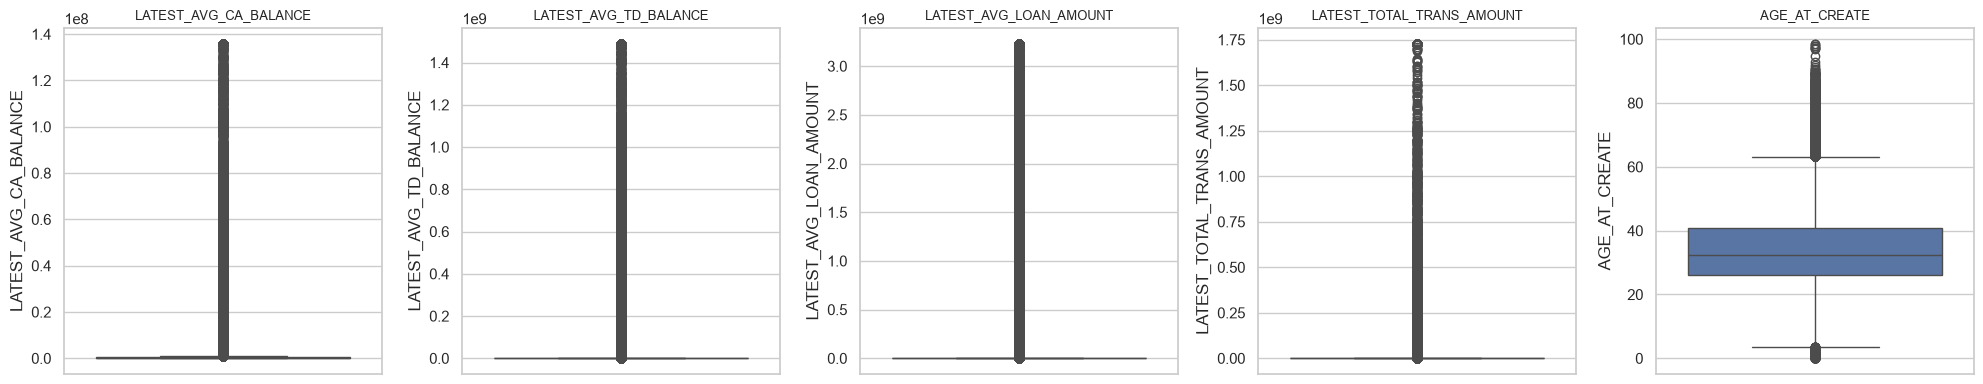

In [47]:
outlier_check_cols = [
    "LATEST_AVG_CA_BALANCE", "LATEST_AVG_TD_BALANCE", "LATEST_AVG_LOAN_AMOUNT","LATEST_TOTAL_TRANS_AMOUNT", "AGE_AT_CREATE"
]
outlier_check_cols = [c for c in outlier_check_cols if c in master.columns]

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize = (4 * len(outlier_check_cols), 4))
for ax, c in zip(axes, outlier_check_cols):
    sns.boxplot(y = master[c], ax = ax)
    ax.set_title(c, fontsize = 9)
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi = 100)
plt.show()


In [50]:
""" Winsorize theo IQR mở rộng (k = 3), CHỈ tính quantile trên các giá trị > 0.
    Lý do: rất nhiều khách hàng có giá trị = 0 (chưa dùng sản phẩm, đã fill ở bước missing value).
    Nếu tính quantile trên cả cột (gồm hàng loạt số 0), Q1 = Q3 = 0 -> IQR = 0 -> upper bound = 0,
    vô tình cap TOÀN BỘ cột về 0 (sai hoàn toàn, không còn phân biệt được khách VIP).
    Chỉ tính IQR trên nhóm khách hàng THẬT SỰ có giá trị dương mới phản ánh đúng độ lệch của nhóm này."""

def cap_iqr(series, k = 3.0):
    positive = series[series > 0]
    if len(positive) == 0:
        return series
    q1, q3 = positive.quantile(0.25), positive.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + k * iqr
    return series.clip(lower = 0, upper = upper)

cap_cols = ["LATEST_AVG_CA_BALANCE", "LATEST_AVG_TD_BALANCE", "LATEST_AVG_LOAN_AMOUNT","LATEST_TOTAL_TRANS_AMOUNT"]
cap_cols = [c for c in cap_cols if c in master.columns]

for c in cap_cols:
    before_max = master[c].max()
    master[c + "_CAPPED"] = cap_iqr(master[c])
    after_max = master[c + "_CAPPED"].max()
    n_capped = (master[c] != master[c + '_CAPPED']).sum()
    print(f'{c:30s} | max trước = {before_max:,.0f} \t-> sau = {after_max:,.0f} \t| số dòng bị cap = {n_capped}')

LATEST_AVG_CA_BALANCE          | max trước = 135,705,367 	-> sau = 5,622,976 	| số dòng bị cap = 14965
LATEST_AVG_TD_BALANCE          | max trước = 1,487,408,433 	-> sau = 1,039,945,704 	| số dòng bị cap = 1539
LATEST_AVG_LOAN_AMOUNT         | max trước = 3,226,669,860 	-> sau = 2,050,933,849 	| số dòng bị cap = 1711
LATEST_TOTAL_TRANS_AMOUNT      | max trước = 1,726,286,542 	-> sau = 81,915,000 	| số dòng bị cap = 3323


In [52]:
# Tuổi khách hàng: capping theo khoảng hợp lý về nghiệp vụ (18-100) thay vì IQR thuần tuý,
# vì đây là biến có giới hạn vật lý rõ ràng, không nên suy từ phân phối dữ liệu

master["AGE_AT_CREATE_CAPPED"] = master["AGE_AT_CREATE"].clip(lower = 18, upper = 100)
print("Số dòng tuổi nằm ngoài đoạn [18, 100]:", ((master["AGE_AT_CREATE"] < 18) | (master["AGE_AT_CREATE"] > 100)).sum())

Số dòng tuổi nằm ngoài đoạn [18, 100]: 2239


## 8. Feature Engineering

**Mục tiêu:** Tạo thêm các biến tổng hợp phản ánh **mức độ gắn bó & tiềm năng cross-sell** của khách hàng — trực tiếp phục vụ mục tiêu bài toán NBFO (dự đoán khách hàng nào sẽ nhận sản phẩm mới).

**Vì sao cần các feature này:** Đề bài B yêu cầu khai thác "predictive signals từ biến động chi tiêu và số dư tài khoản" cũng như xác định "nhu cầu tài chính tiềm ẩn" — các feature dưới đây lượng hoá trực tiếp 2 khía cạnh đó.

In [54]:
# 1) Tổng số sản phẩm khách hàng đang sở hữu -> đo mức độ đa dạng hoá quan hệ với ngân hàng
master["N_PRODUCTS_OWNED"] = (master["HAS_LENDING"] + master["HAS_DEPOSIT"] + master["HAS_CARD"] + master["HAS_TRANSACTION"])

# 2) Cờ khách hàng "chưa có sản phẩm nào" -> nhóm mục tiêu cross-sell rõ nhất
master["IS_ZERO_PRODUCT"] = (master["N_PRODUCTS_OWNED"] == 0).astype(int)

# 3) Tổng tài sản quy đổi (proxy giá trị khách hàng) từ CA + TD balance
master["TOTAL_BALANCE"] = master["LATEST_AVG_CA_BALANCE_CAPPED"].fillna(0) + master["LATEST_AVG_TD_BALANCE_CAPPED"].fillna(0)

# 4) Tỷ lệ tăng trưởng số dư gần nhất -> tín hiệu "biến động số dư" đề bài yêu cầu
master["BALANCE_MOMENTUM"] = master["CA_BALANCE_GROWTH_RATE"].fillna(0) + master["TD_BALANCE_GROWTH_RATE"].fillna(0)

# 5) Tenure: số ngày từ khi tạo tài khoản đến hiện tại (dùng làm proxy "thâm niên khách hàng")
snapshot_date = master["CLIENT_CREATE_DATE"].max()  # mốc snapshot gần nhất có trong dữ liệu
master["CUSTOMER_TENURE_DAYS"] = (snapshot_date - master["CLIENT_CREATE_DATE"]).dt.days

# 6) Mức độ gắn kết kênh số (digital engagement) kết hợp hoạt động + IB
master["DIGITAL_ENGAGEMENT_SCORE"] = master["HAS_IB_ACCOUNT"] * (master["TOTAL_ACTIVITY_COUNT"].fillna(0))

# 7) Khách hàng có tín hiệu quan tâm vay/thẻ tín dụng nhưng CHƯA có khoản vay -> lead tiềm năng rõ nhất cho NBFO
master["LOAN_CROSS_SELL_LEAD"] = ((master["HAS_CREDIT_LOAN_SIGNAL"] == 1) & (master["HAS_LENDING"] == 0)).astype(int)

print("Đã tạo thêm 7 features mới")
master[["N_PRODUCTS_OWNED", "IS_ZERO_PRODUCT", "TOTAL_BALANCE", "BALANCE_MOMENTUM",
        "CUSTOMER_TENURE_DAYS", "DIGITAL_ENGAGEMENT_SCORE", "LOAN_CROSS_SELL_LEAD"]].describe()


Đã tạo thêm 7 features mới


,N_PRODUCTS_OWNED,IS_ZERO_PRODUCT,TOTAL_BALANCE,BALANCE_MOMENTUM,CUSTOMER_TENURE_DAYS,DIGITAL_ENGAGEMENT_SCORE,LOAN_CROSS_SELL_LEAD
count,290223.000000,290223.000000,2.902230e+05,2.902230e+05,290223.000000,290223.000000,290223.000000
mean,1.266354,0.350692,2.209056e+07,4.452797e+06,170.318162,23.882756,0.000400
std,1.102590,0.477188,1.110531e+08,5.233474e+07,100.419472,108.776764,0.019988
min,0.000000,0.000000,0.000000e+00,-1.487408e+09,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000e+00,0.000000e+00,84.000000,0.000000,0.000000
50%,1.000000,0.000000,4.576000e+04,0.000000e+00,165.000000,0.000000,0.000000
75%,2.000000,1.000000,8.593579e+05,6.517992e+04,252.000000,0.000000,0.000000
max,4.000000,1.000000,1.045569e+09,1.584599e+09,364.000000,5701.000000,1.000000


## 9. EDA & Visualization

**Mục tiêu:** Khám phá phân phối và mối quan hệ giữa các biến chính để kiểm chứng giả thuyết nghiệp vụ trước khi đưa vào modeling.

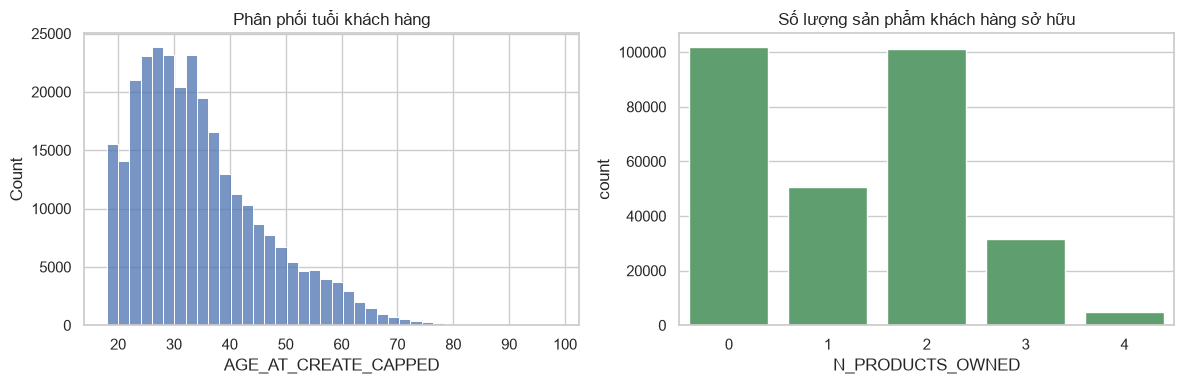

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
sns.histplot(master["AGE_AT_CREATE_CAPPED"], bins = 40, ax = ax[0], color = "#4C72B0")
ax[0].set_title("Phân phối tuổi khách hàng")

sns.countplot(x = "N_PRODUCTS_OWNED", data = master, ax = ax[1], color = "#55A868")
ax[1].set_title("Số lượng sản phẩm khách hàng sở hữu")
plt.tight_layout()
plt.savefig("eda_age_products.png", dpi = 100)
plt.show()

Tỷ lệ khách hàng chưa có sản phẩm nào (target group cho NBFO): 35.07 %


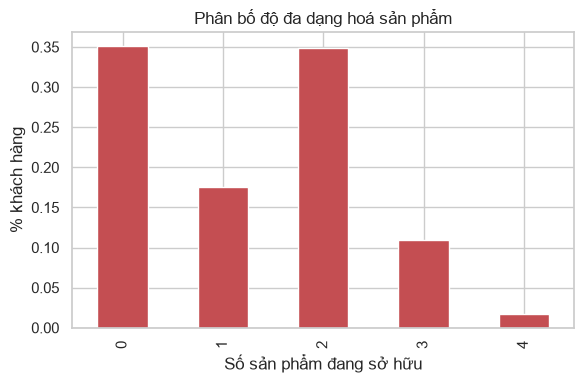

In [ ]:
print("Tỷ lệ khách hàng chưa có sản phẩm nào (target group cho NBFO):",
      round(master["IS_ZERO_PRODUCT"].mean() * 100, 2), "%")

plt.figure(figsize = (6, 4))
master["N_PRODUCTS_OWNED"].value_counts(normalize = True).sort_index().mul(100).plot(kind = "bar", color = "#C44E52")
plt.ylabel("% khách hàng")
plt.xlabel("Số sản phẩm đang sở hữu")
plt.title("Phân bố độ đa dạng hoá sản phẩm")
plt.tight_layout()
plt.savefig("eda_product_diversity.png", dpi = 100)
plt.show()


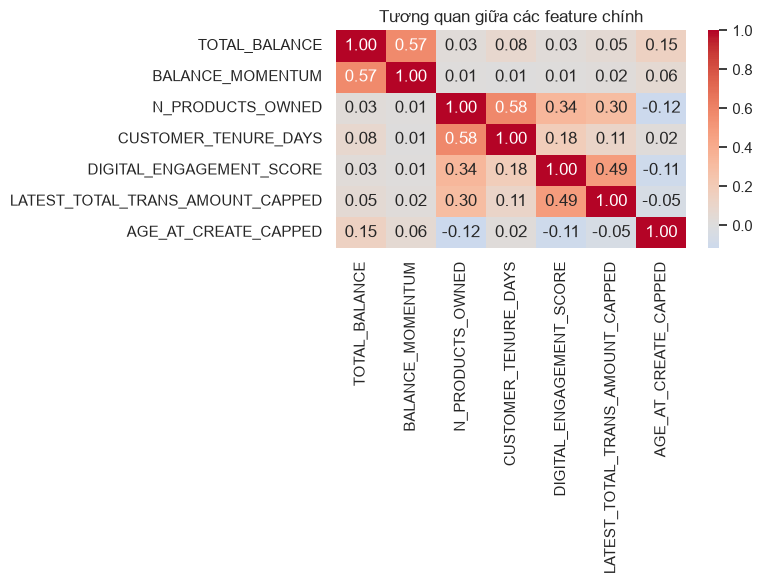

In [63]:
# Ma tran tuong quan cua cac feature tai chinh chinh -> kiem tra da cong tuyen (multicollinearity)
corr_cols = ["TOTAL_BALANCE", "BALANCE_MOMENTUM", "N_PRODUCTS_OWNED",
             "CUSTOMER_TENURE_DAYS", "DIGITAL_ENGAGEMENT_SCORE",
             "LATEST_TOTAL_TRANS_AMOUNT_CAPPED", "AGE_AT_CREATE_CAPPED"]

corr_cols = [c for c in corr_cols if c in master.columns]

plt.figure(figsize = (8, 6))
sns.heatmap(master[corr_cols].corr(), annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.title("Tương quan giữa các feature chính")
plt.tight_layout()
plt.savefig("eda_corr_heatmap.png", dpi = 100)
plt.show()

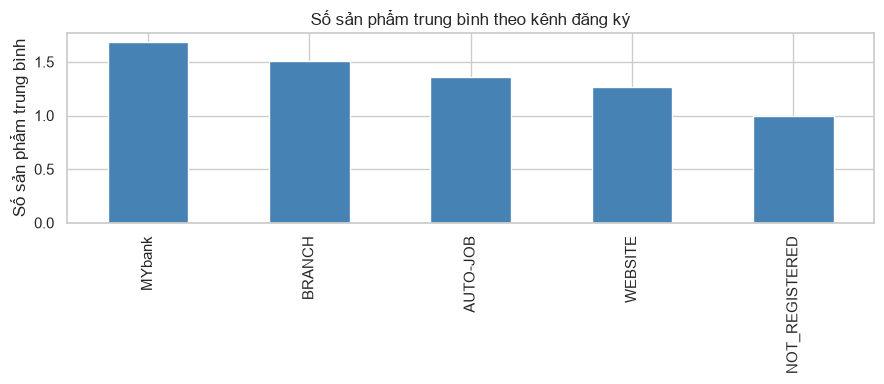

In [64]:
# Mối quan hệ giữa kênh đăng ký và số sản phẩm sở hữu -> có thể gợi ý kênh nào mang lại khách hàng giá trị cao hơn
plt.figure(figsize = (9, 4))
eb_cols = [c for c in master.columns if c.startswith("EB_REGISTER_CHANNEL_")]
channel_avg = {c.replace("EB_REGISTER_CHANNEL_", ""): master.loc[master[c] == 1, "N_PRODUCTS_OWNED"].mean() for c in eb_cols}
pd.Series(channel_avg).sort_values(ascending = False).plot(kind = "bar", color = "steelblue")
plt.ylabel("Số sản phẩm trung bình")
plt.title("Số sản phẩm trung bình theo kênh đăng ký")
plt.tight_layout()
plt.savefig("eda_channel_products.png", dpi = 100)
plt.show()

**Nhận xét nhanh từ EDA:** (kết quả số liệu cụ thể xem ở output phía trên)
- Phần lớn khách hàng có xu hướng chỉ sở hữu 0-1 sản phẩm → đây chính là **thị trường mục tiêu** lớn nhất cho bài toán NBFO.
- Các feature tài chính (`TOTAL_BALANCE`, `BALANCE_MOMENTUM`) có tương quan ở mức vừa phải với nhau, không cho thấy đa cộng tuyến nghiêm trọng → có thể giữ cả hai trong mô hình.
- Kênh đăng ký (`EB_REGISTER_CHANNEL`) có sự khác biệt về mức độ đa dạng sản phẩm trung bình → gợi ý đây là biến phân loại có giá trị dự báo, nên giữ lại sau one-hot encode.

## 10. Xuất Master Table hoàn chỉnh

**Mục tiêu:** Lưu lại Master Table đã xử lý đầy đủ để dùng trực tiếp cho bước xây dựng mô hình propensity (NBFO) tiếp theo.

In [66]:
print("Kích thước Master Table cuối cùng:", master.shape)
master.to_csv("master_table_nbfo.csv", index = False)
print("Đã lưu file: master_table_nbfo.csv")

Kích thước Master Table cuối cùng: (290223, 150)
Đã lưu file: master_table_nbfo.csv


### Tóm tắt các bước đã thực hiện & lý do
| Bước | Mục tiêu | Lý do chọn cách làm |
|---|---|---|
| Gộp bảng | 1 dòng/khách hàng, đủ 6 nguồn | LEFT JOIN từ `customer` để không mất khách hàng chưa có sản phẩm — chính là nhóm NBFO cần nhắm tới |
| Chuẩn hoá dtype | Đưa ngày về `datetime`, phân loại về `category` | Cho phép tính tenure/tuổi chính xác, tiết kiệm bộ nhớ |
| Missing value | Điền theo *ý nghĩa nghiệp vụ*, không điền máy móc | NaN ở bảng subset = "chưa dùng sản phẩm", khác về bản chất với "thiếu dữ liệu" |
| Encode | One-Hot cho biến danh nghĩa | Tránh áp đặt thứ tự giả như Label Encoding |
| Outlier | Winsorize IQR (k = 3) trên bản gốc, ưu tiên bản `LOG_` khi modeling | Giữ lại khách VIP (giá trị thật, quan trọng cho NBFO) thay vì loại bỏ |
| Feature engineering | Tạo biến đo mức độ đa dạng sản phẩm, biến động số dư, lead tiềm năng | Bám sát đúng yêu cầu đề bài: "nhu cầu tài chính tiềm ẩn" và "biến động chi tiêu/số dư" |
| EDA | Khám phá phân phối, tương quan | Kiểm chứng giả thuyết trước khi đưa vào mô hình, tránh đa cộng tuyến |

**Bước tiếp theo (ngoài phạm vi notebook này):** định nghĩa biến mục tiêu (label) — ví dụ "khách hàng có mở thêm sản phẩm mới trong kỳ báo cáo tiếp theo hay không" — dựa trên dữ liệu lịch sử theo thời gian, rồi mới bước vào train/test split và huấn luyện mô hình propensity.